In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Visualization**

In [16]:
cleaned_df = pd.read_csv("../cleaned_dataset.csv")
encoded_df = pd.read_csv("../encoded_dataset.csv")

### **Distribution of Age**

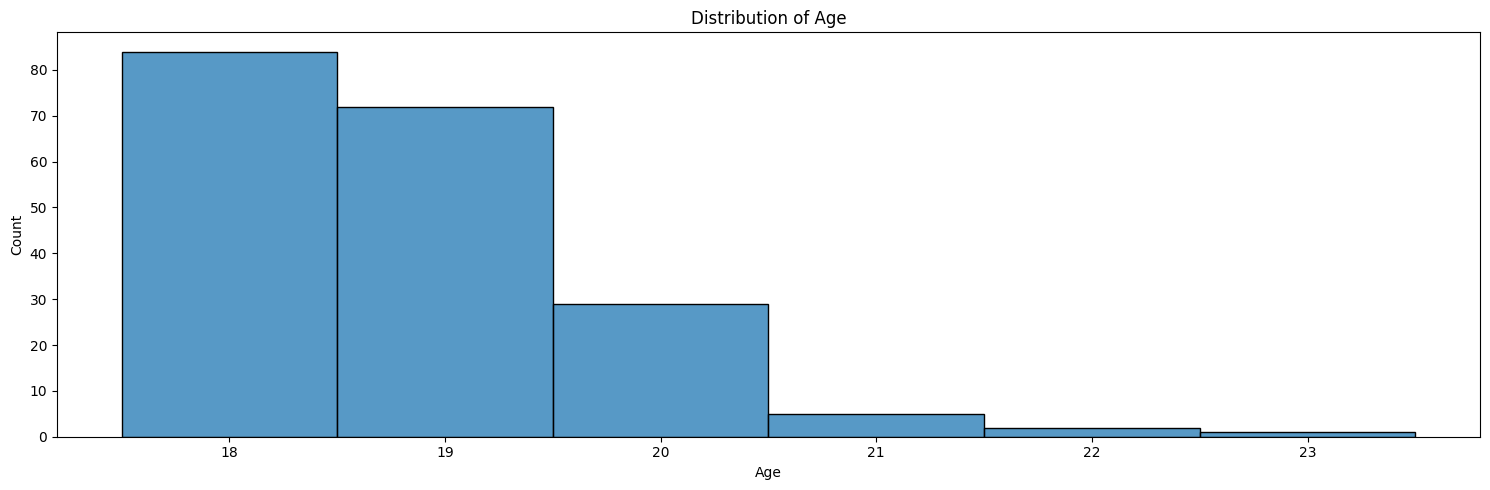

In [17]:
# Histogram of age
plt.figure(figsize=(15, 5))

sns.histplot(cleaned_df["age"], discrete=True)
plt.title("Distribution of Age")

plt.tight_layout()
plt.xlabel("Age")
plt.show()

### **Distribution of Gender**

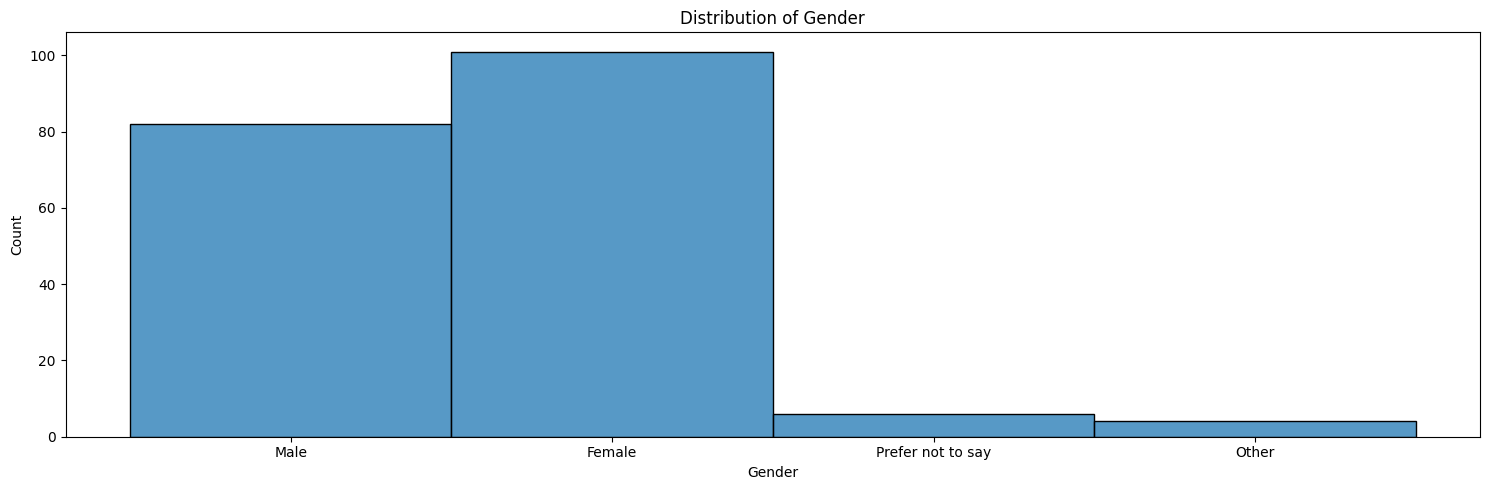

In [18]:
# Histogram of gender
plt.figure(figsize=(15, 5))

sns.histplot(cleaned_df["gender"])
plt.title("Distribution of Gender")

plt.tight_layout()
plt.xlabel("Gender")
plt.show()

### **Distribution of GPA**

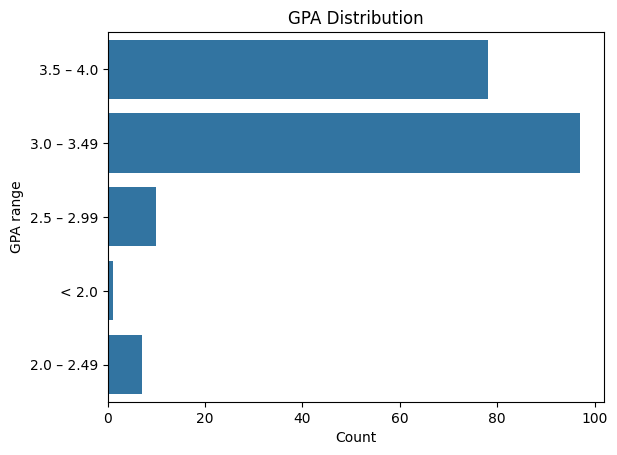

In [19]:
# Visulization of gpa
sns.countplot(data=cleaned_df["gpa_range"])
plt.title("GPA Distribution")
plt.xlabel("Count")
plt.ylabel("GPA range")
plt.show()

### **Study Hours vs GPA**

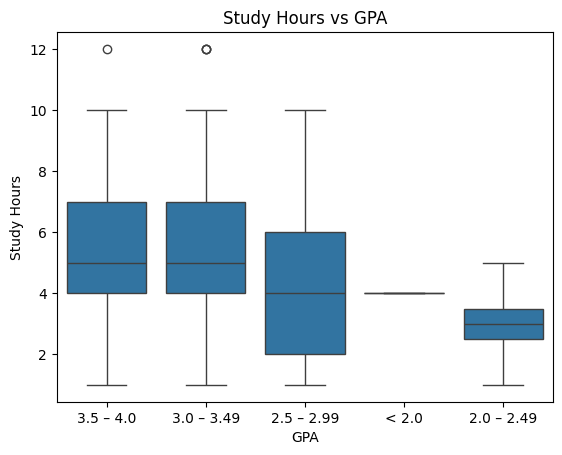

In [20]:
# Correlation between gpa and self-studying hours
sns.boxplot(
    x=cleaned_df["gpa_range"], y=cleaned_df["self_study_hours"], data=cleaned_df
)
plt.title("Study Hours vs GPA")
plt.xlabel("GPA")
plt.ylabel("Study Hours")
plt.show()

### **Distribution of demographic features**

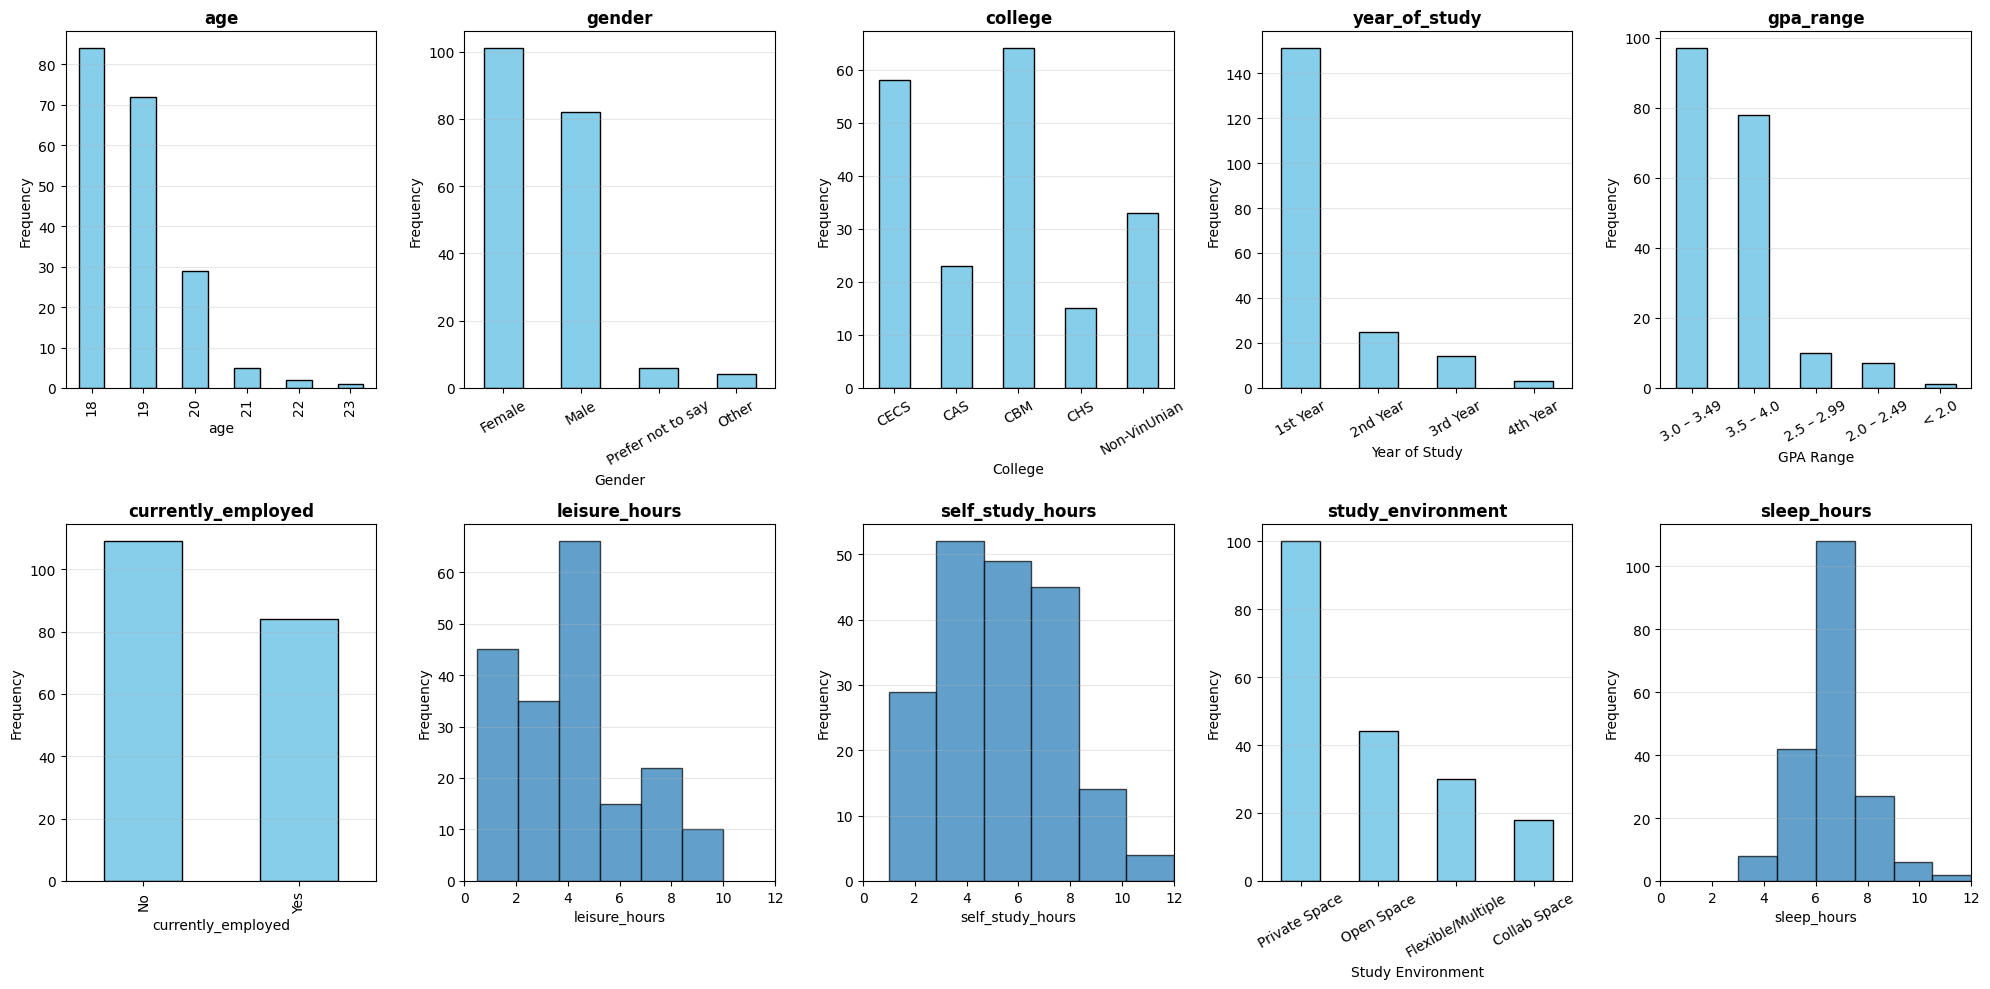

In [21]:
# Multi-column histogram subplots (first 10 columns excluding timestamp)
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

# Flatten axes array for easier iteration
axes = axes.flatten()

# Get first 10 columns excluding timestamp
columns_to_plot = [col for col in cleaned_df.columns if col != "timestamp"][:10]

college_map = {
    "CECS (Engineering & Computer Science)": "CECS",
    "CAS (Arts and Sciences)": "CAS",
    "CBM (Business and Management)": "CBM",
    "CHS (Health Science)": "CHS",
}
college_order = ["CECS", "CAS", "CBM", "CHS", "Non-VinUnian"]

# Create histogram for each column
for idx, col in enumerate(columns_to_plot):
    ax = axes[idx]

    if col == "college":
        college_grouped = cleaned_df[col].map(college_map).fillna("Non-VinUnian")
        college_grouped.value_counts().reindex(college_order, fill_value=0).plot(
            kind="bar", ax=ax, color="skyblue", edgecolor="black"
        )
    elif cleaned_df[col].dtype in ["float64", "int64"] and col != "age":
        ax.hist(cleaned_df[col], bins=6, edgecolor="black", alpha=0.7)
        ax.set_xlim(0, 12)
        ax.set_xticks(range(0, 13, 2))
    elif col == "age":
        cleaned_df[col].value_counts().sort_index().plot(
            kind="bar", ax=ax, color="skyblue", edgecolor="black"
        )
    else:
        cleaned_df[col].value_counts().plot(
            kind="bar", ax=ax, color="skyblue", edgecolor="black"
        )

    ax.set_title(f"{col}", fontweight="bold")
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.3)

    if col == "college":
        ax.tick_params(axis="x", rotation=30)
        ax.set_xlabel("College")
    elif col == "year_of_study":
        ax.tick_params(axis="x", rotation=30)
        ax.set_xlabel("Year of Study")
    elif col == "gpa_range":
        ax.tick_params(axis="x", rotation=30)
        ax.set_xlabel("GPA Range")
    elif col == "study_environment":
        ax.tick_params(axis="x", rotation=30)
        ax.set_xlabel("Study Environment")
    elif col == "gender":
        ax.tick_params(axis="x", rotation=30)
        ax.set_xlabel("Gender")
    else:
        ax.set_xlabel(col)

plt.tight_layout()
plt.show()


### **Correlation heatmap**

Text(0.5, 1.0, 'Heatmap correlation between all features')

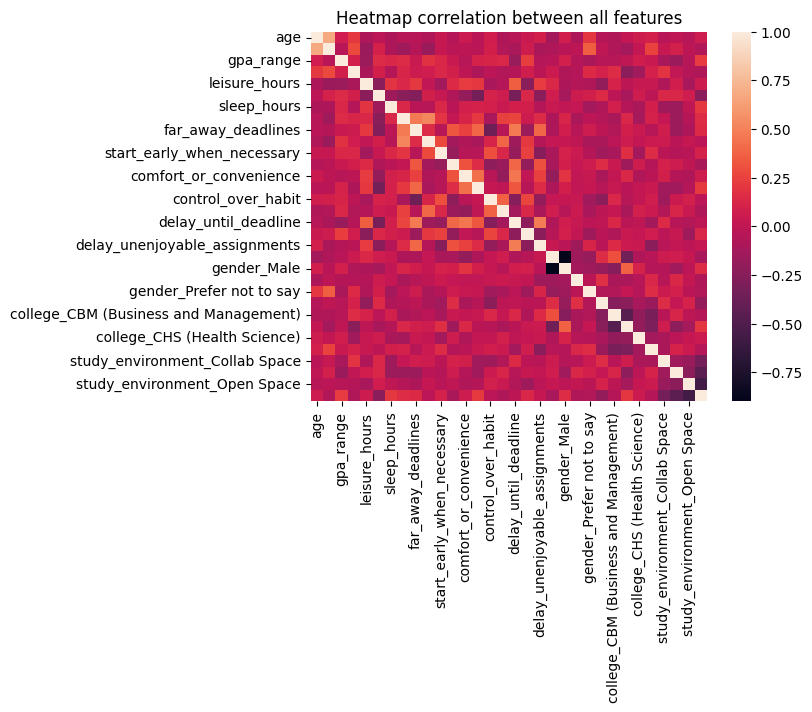

In [22]:
sns.heatmap(
    encoded_df.drop(columns=["timestamp", "data_quality_check", "referrer"]).corr()
)
plt.title("Heatmap correlation between all features")

### **Distribution of Linkert Features**

In [23]:
linkert_col = [
    "impact_on_learning_progress",
    "far_away_deadlines",
    "study_plan",
    "start_early_when_necessary",
    "difficult_to_maintain",
    "comfort_or_convenience",
    "peers_consider_normal",
    "control_over_habit",
    "sooner_next_month",
    "delay_until_deadline",
]

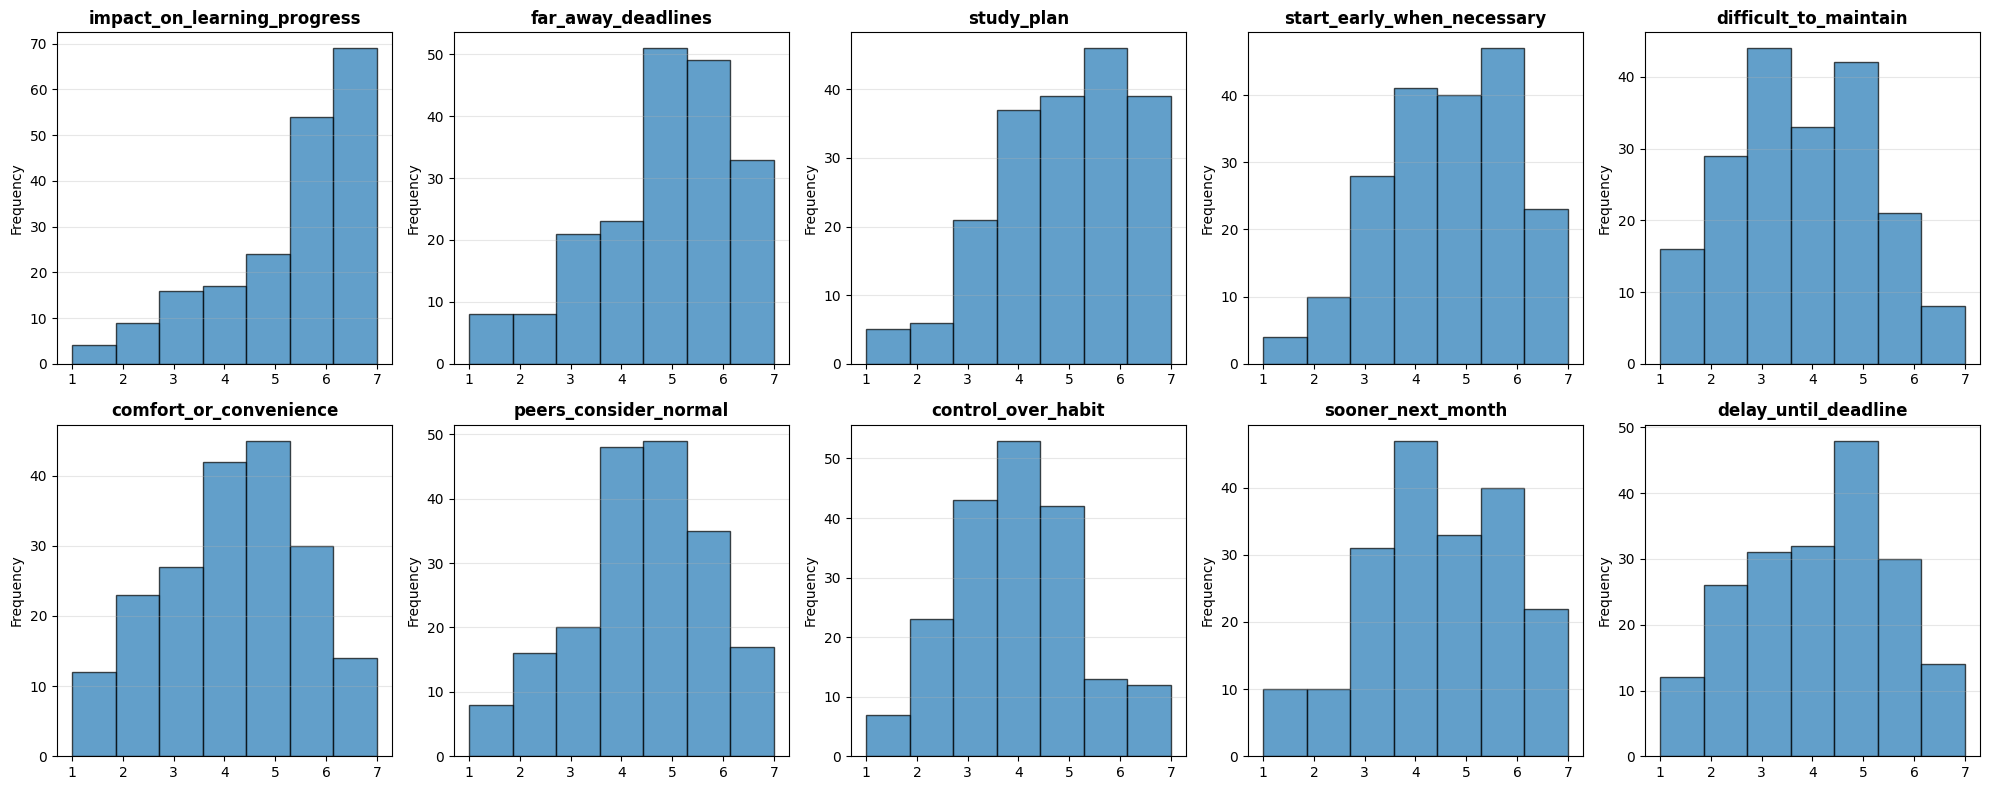

In [24]:
# Multi-column histogram subplots (first 10 columns excluding timestamp)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Flatten axes array for easier iteration
axes = axes.flatten()


# Create histogram for each column
for idx, col in enumerate(linkert_col):
    ax = axes[idx]

    ax.hist(encoded_df[col], bins=7, edgecolor="black", alpha=0.7)

    ax.set_title(f"{col}", fontweight="bold")
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.3)


plt.tight_layout()
plt.show()

### **100% Stacked Bar Chart for Likert Items**


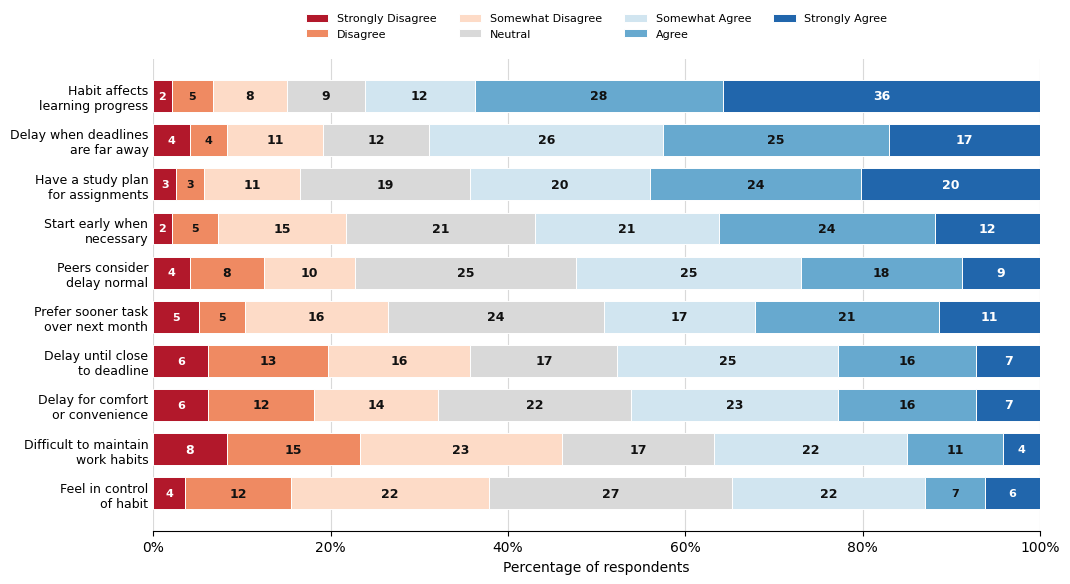

In [25]:
from pathlib import Path
from matplotlib.ticker import PercentFormatter

likert_columns = [
    "impact_on_learning_progress",
    "far_away_deadlines",
    "study_plan",
    "start_early_when_necessary",
    "difficult_to_maintain",
    "comfort_or_convenience",
    "peers_consider_normal",
    "control_over_habit",
    "sooner_next_month",
    "delay_until_deadline",
]

question_labels = {
    "impact_on_learning_progress": "Habit affects\nlearning progress",
    "far_away_deadlines": "Delay when deadlines\nare far away",
    "study_plan": "Have a study plan\nfor assignments",
    "start_early_when_necessary": "Start early when\nnecessary",
    "difficult_to_maintain": "Difficult to maintain\nwork habits",
    "comfort_or_convenience": "Delay for comfort\nor convenience",
    "peers_consider_normal": "Peers consider\ndelay normal",
    "control_over_habit": "Feel in control\nof habit",
    "sooner_next_month": "Prefer sooner task\nover next month",
    "delay_until_deadline": "Delay until close\nto deadline",
}

likert_order = [
    "Strongly Disagree",
    "Disagree",
    "Somewhat Disagree",
    "Neutral",
    "Somewhat Agree",
    "Agree",
    "Strongly Agree",
]

likert_colors = {
    "Strongly Disagree": "#b2182b",
    "Disagree": "#ef8a62",
    "Somewhat Disagree": "#fddbc7",
    "Neutral": "#d9d9d9",
    "Somewhat Agree": "#d1e5f0",
    "Agree": "#67a9cf",
    "Strongly Agree": "#2166ac",
}

counts = pd.DataFrame(index=likert_columns, columns=likert_order, dtype=float)
for column in likert_columns:
    counts.loc[column] = cleaned_df[column].value_counts().reindex(likert_order, fill_value=0)

percentages = counts.div(counts.sum(axis=1), axis=0) * 100
percentages["Agree total"] = percentages[
    ["Somewhat Agree", "Agree", "Strongly Agree"]
].sum(axis=1)
percentages = percentages.sort_values("Agree total", ascending=True)

plot_data = percentages[likert_order]
labels = [question_labels[column] for column in plot_data.index]

fig, ax = plt.subplots(figsize=(10.8, 6.4))
left = pd.Series(0, index=plot_data.index, dtype=float)

for category in likert_order:
    values = plot_data[category]
    ax.barh(
        labels,
        values,
        left=left,
        height=0.72,
        label=category,
        color=likert_colors[category],
        edgecolor="white",
        linewidth=0.7,
    )
    for y_pos, (start, value) in enumerate(zip(left, values)):
        if value > 0:
            ax.text(
                start + value / 2,
                y_pos,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=8 if value < 7 else 9,
                fontweight="bold",
                color="#ffffff" if category in {"Strongly Disagree", "Strongly Agree"} else "#111111",
            )
    left += values

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_xlabel("Percentage of respondents")
ax.set_ylabel("")
ax.grid(axis="x", color="#d0d0d0", linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=9)
ax.legend(
    ncols=4,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    frameon=False,
    fontsize=8,
)

fig.tight_layout(rect=(0, 0, 1, 0.93))

figure_dir = Path("../figures")
figure_dir.mkdir(exist_ok=True)
fig.savefig(figure_dir / "likert_100_stacked_bar.png", dpi=300, bbox_inches="tight")
fig.savefig(figure_dir / "likert_100_stacked_bar.pdf", bbox_inches="tight")

output_table = percentages[likert_order + ["Agree total"]].round(2)
output_table.index = [question_labels[column].replace("\n", " ") for column in output_table.index]
output_table.to_csv(figure_dir / "likert_100_stacked_bar_percentages.csv")

plt.show()
